**A. Membangun Struktur Direktori HDFS** *(bobot 15%)*

Buatlah struktur direktori berikut di HDFS:
```
/user/[username]/ecommerce/raw
/user/[username]/ecommerce/processed
```
Tampilkan hasilnya untuk membuktikan struktur sudah terbentuk.

In [2]:
# Membuat direktori raw dan processed
!hdfs dfs -mkdir -p /user/nexvandar/ecommerce/raw
!hdfs dfs -mkdir -p /user/nexvandar/ecommerce/processed

# Menampilkan hasilnya (menggunakan -R untuk melihat isi subdirektori)
!hdfs dfs -ls -R /user/nexvandar/ecommerce

drwxr-xr-x   - nexvandar supergroup          0 2026-09-04 02:58 /user/nexvandar/ecommerce/processed
drwxr-xr-x   - nexvandar supergroup          0 2026-09-04 02:58 /user/nexvandar/ecommerce/raw


**B. Mengunggah Data Mentah ke HDFS** *(bobot 15%)*

Unggah **ketiga berkas CSV** (`transaksi_magelang.csv`, `transaksi_yogyakarta.csv`, `transaksi_semarang.csv`) ke direktori `/user/[username]/ecommerce/raw` di HDFS. Tampilkan isi direktori tersebut sebagai bukti ketiga berkas berhasil terunggah, lengkap dengan ukurannya.

In [3]:
# Mengunggah ketiga berkas CSV ke HDFS
!hdfs dfs -put transaksi_magelang.csv transaksi_yogyakarta.csv transaksi_semarang.csv /user/nexvandar/ecommerce/raw/

# Menampilkan isi direktori raw untuk membuktikan berkas terunggah beserta ukurannya
!hdfs dfs -ls /user/nexvandar/ecommerce/raw

Found 3 items
-rw-r--r--   1 nexvandar supergroup      12329 2026-09-04 03:01 /user/nexvandar/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 nexvandar supergroup      12154 2026-09-04 03:01 /user/nexvandar/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 nexvandar supergroup      12684 2026-09-04 03:01 /user/nexvandar/ecommerce/raw/transaksi_yogyakarta.csv


**C. Membaca Kembali dan Menggabungkan Data dari HDFS** *(bobot 25%)*

Menggunakan Python, baca kembali **ketiga berkas dari HDFS** (bukan dari disk lokal!). Gabungkan ketiganya menjadi **satu DataFrame**, lalu buktikan hasil gabungan berisi transaksi dari ketiga kota (tampilkan `value_counts()` pada kolom `kota`).

In [5]:
!pip install fsspec pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 4.2 MB/s  0:00:11 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [fsspec]━━━━ 1/2 [fsspec]


In [8]:
import pandas as pd
import subprocess
import io

# Fungsi pembantu untuk membaca langsung dari HDFS ke memori Pandas (tanpa simpan lokal)
def baca_dari_hdfs(path):
    # Memanggil perintah HDFS untuk membaca berkas
    proses = subprocess.Popen(["hdfs", "dfs", "-cat", path], stdout=subprocess.PIPE)
    output, error = proses.communicate()
    # Membaca aliran bytes tersebut menjadi DataFrame Pandas
    return pd.read_csv(io.BytesIO(output))

# Membaca data langsung dari HDFS
path_magelang = "/user/nexvandar/ecommerce/raw/transaksi_magelang.csv"
path_yogya = "/user/nexvandar/ecommerce/raw/transaksi_yogyakarta.csv"
path_semarang = "/user/nexvandar/ecommerce/raw/transaksi_semarang.csv"

df_magelang = baca_dari_hdfs(path_magelang)
df_yogya = baca_dari_hdfs(path_yogya)
df_semarang = baca_dari_hdfs(path_semarang)

# Menggabungkan ketiga DataFrame
df_gabungan = pd.concat([df_magelang, df_yogya, df_semarang], ignore_index=True)

# Membuktikan hasil gabungan berisi transaksi dari ketiga kota
print(df_gabungan['kota'].value_counts())

kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


**D. Mengolah dan Download Hasil ke Direktori `processed`** *(bobot 25%)*

Pada DataFrame gabungan hasil bagian C:
1. Tambahkan kolom `total_pendapatan` (`unit_terjual x harga_satuan`).
2. Buatlah **satu tabel ringkasan** (`groupby`) yang menampilkan total pendapatan per kota **dan** per kategori sekaligus.
3. Simpan **dua** hasil berikut sebagai berkas CSV baru di disk lokal, lalu unggah keduanya ke `/user/[username]/ecommerce/processed` di HDFS:
   - `data_gabungan_bersih.csv` (seluruh data ketiga kota yang telah digabung + kolom `total_pendapatan`)
   - `ringkasan_kota_kategori.csv` (tabel ringkasan dari langkah 2)

In [9]:
# 1. Menambahkan kolom total_pendapatan
df_gabungan['total_pendapatan'] = df_gabungan['unit_terjual'] * df_gabungan['harga_satuan']

# 2. Membuat tabel ringkasan per kota dan kategori
ringkasan = df_gabungan.groupby(['kota', 'kategori'])['total_pendapatan'].sum().reset_index()

# Menampilkan sedikit cuplikan hasil ringkasan
display(ringkasan.head())

# 3. Menyimpan hasil ke disk lokal
df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
ringkasan.to_csv("ringkasan_kota_kategori.csv", index=False)

# Mengunggah kedua hasil tersebut ke HDFS (direktori processed)
!hdfs dfs -put data_gabungan_bersih.csv ringkasan_kota_kategori.csv /user/nexvandar/ecommerce/processed/

# Verifikasi file sudah ada di folder processed
!hdfs dfs -ls /user/nexvandar/ecommerce/processed

,kota,kategori,total_pendapatan
0,Magelang,Elektronik,18775000
1,Magelang,Fashion,27750000
2,Magelang,Kesehatan & Kecantikan,17375000
3,Magelang,Makanan & Minuman,17525000
4,Magelang,Rumah Tangga,12200000


Found 2 items
-rw-r--r--   1 nexvandar supergroup      41257 2026-09-04 03:15 /user/nexvandar/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 nexvandar supergroup        530 2026-09-04 03:15 /user/nexvandar/ecommerce/processed/ringkasan_kota_kategori.csv


**E. Dokumentasi dan Refleksi** *(bobot 20%)*

Sertakan pada notebook anda:
1. **Screenshot** halaman NameNode Web UI (http://localhost:9870, menu *Utilities → Browse the file system*) yang menunjukkan struktur folder `/user/[username]/ecommerce/` beserta isinya (paste gambar ke dalam markdown cell, atau lampirkan terpisah jika format pengumpulan berupa arsip/zip.
2. Tulisan reflektif (**minimal 100 kata**) pada markdown cell yang menjawab: *Apa keuntungan menyimpan data mentah (raw) terpisah dari data olahan (processed) di HDFS, dibandingkan menyimpan semuanya bercampur dalam satu folder?*

**1. Screenshot**

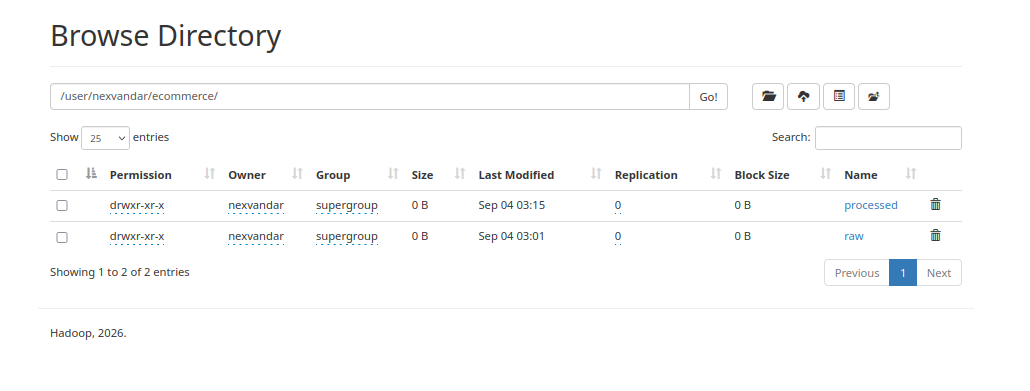
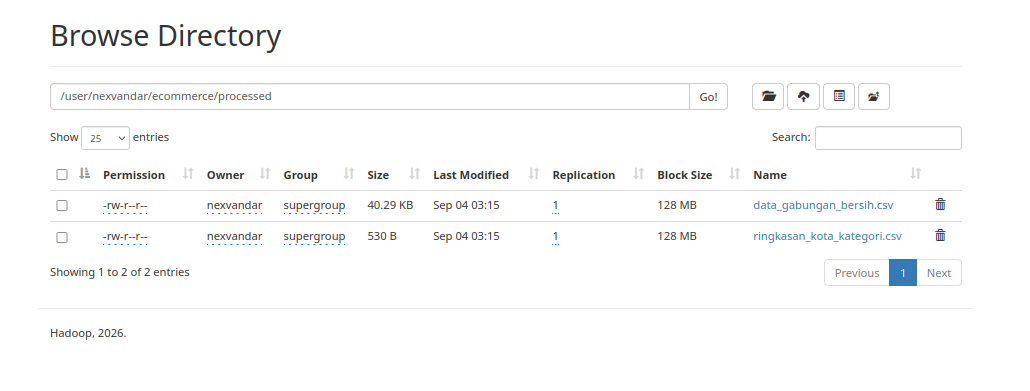
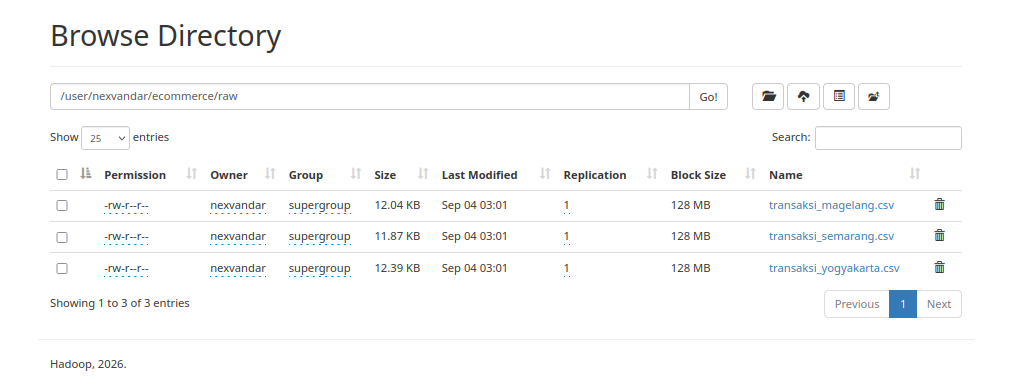

**2. Refleksi Pemisahan Data Raw dan Processed**

Menyimpan data mentah (raw) secara terpisah dari data olahan (processed) di HDFS memberikan berbagai keuntungan strategis bagi tim data. Pertama, hal ini memastikan Single Source of Truth; jika terjadi kesalahan dalam logika pemrosesan data, kita selalu memiliki data asli yang tidak tersentuh untuk memproses ulang (reprocess) tanpa takut kehilangan informasi awal. Kedua, struktur ini menjaga kerapian alur kerja (data pipeline), sehingga analis atau data engineer lain dapat dengan mudah mengidentifikasi mana data yang siap pakai untuk dashboarding dan mana data yang masih perlu tahapan cleaning. Terakhir, pemisahan ini memudahkan pengaturan hak akses, di mana hanya sistem atau engineer tertentu yang boleh menulis di folder raw, sementara pengguna bisnis hanya diizinkan membaca dari folder processed.